In [1]:
from pathlib import Path
import os

import networkx as nx

In [2]:
path = Path(os.environ["DATADIR"]) / "orqa" / "ckan" / "uk" / "candidates_discovery" / "matches_graph.gml"
path.exists()

True

In [16]:
G = nx.read_gml(path)

In [17]:
G.is_directed(), nx.is_connected(nx.to_undirected(G))

(True, False)

In [19]:
"7965c552-15d0-4b31-bd4c-342f0737d5b2" in G.nodes

False

In [5]:
len(G.nodes), len(G.edges)

(972, 5529)

In [6]:
n = list(G.nodes)[0]
G.out_degree(n)

54

In [ ]:
# [g for f, g in G.out_degree()]

In [7]:
len([(node, degree) for node, degree in G.out_degree() if degree == 0])

872

In [15]:
G.edges[('CSV__1a66e8bb-1ed5-498e-b6ab-ae8a862b1266', 'CSV__1e09f805-5363-4d4b-9194-f9b08f1f70f7', 0)]
sum([1 for edge, data in G.edges.items() if data["label"] == "JC"])

1290

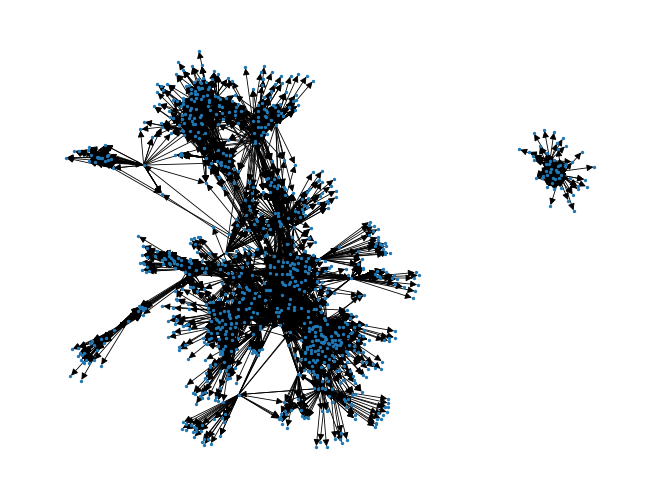

In [8]:
assert isinstance(G, nx.MultiDiGraph)
G.remove_nodes_from([(node, degree) for node, degree in G.out_degree() if degree == 0])
nx.draw(G, node_size=2, width=0.6)